In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
filename = "/lustre/r3b/ywang/calibration/s515/run49x/map/map.par.root"

file = ROOT.TFile(filename, "read")

In [5]:
canvas = ROOT.TCanvas("canvas", "canvas", 600, 300)

In [74]:
hist_dir = file.Get("CalParHistograms")
hist = hist_dir.Get("MapCal_0007_right_leading")

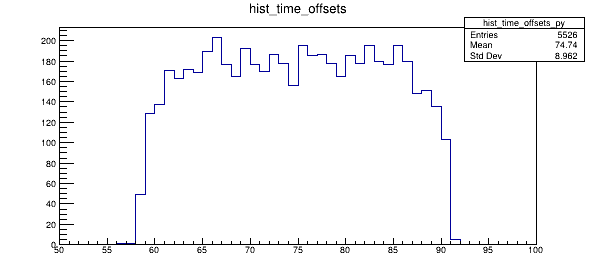

In [81]:
hist.GetYaxis().SetRangeUser(0.0, 600)
hist_proj = hist.ProjectionY("_py", 15, 15)
hist_proj.Draw()
canvas.Draw()

In [82]:
num_of_bins = hist_proj.GetNbinsX()

x_vals = np.zeros(num_of_bins)
y_vals = np.zeros(num_of_bins)
y_sums = np.zeros(num_of_bins)

sum_val = 0.0

for index in range(0, num_of_bins):
    x_vals[index] = index + 1
    y_vals[index] = hist_proj.GetBinContent(index + 1)
    sum_val += y_vals[index]
    y_sums[index] = sum_val

y_sums = y_sums / sum_val * 5

data = pd.DataFrame(
    {"Channels": x_vals, "Entries per channel": y_vals, "Real time (ns)": y_sums}
)

In [41]:
def convert_to_df(hist):
    num_of_bins = hist.GetNbinsX()

    x_vals = np.zeros(num_of_bins)
    y_vals = np.zeros(num_of_bins)
    y_sums = np.zeros(num_of_bins)

    sum_val = 0.0

    for index in range(0, num_of_bins):
        x_vals[index] = hist_proj.GetBinCenter(index + 1)
        y_vals[index] = hist_proj.GetBinContent(index + 1)
        sum_val += y_vals[index]
        y_sums[index] = sum_val

    y_sums = y_sums / sum_val

    return pd.DataFrame({"x": x_vals, "y": y_vals, "CDF": y_sums})

Text(0.5, 1.0, 'CDF (Cumulative distribution function)')

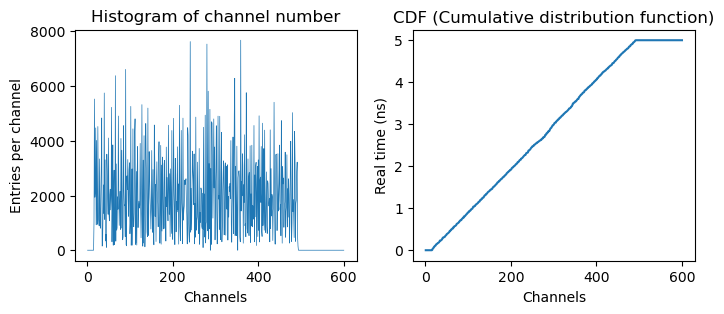

In [83]:
# sns.lineplot(data, x = "x", y = "y")
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.2)
sns.lineplot(
    data, x="Channels", y="Entries per channel", ax=ax[0], linewidth=0.5
).set_title("Histogram of channel number")
sns.lineplot(data, x="Channels", y="Real time (ns)", ax=ax[1]).set_title(
    "CDF (Cumulative distribution function)"
)

In [69]:
import itertools

def convert_2d_to_arrays(histogram):
    nbinsy = histogram.GetNbinsY()
    nbinsx = histogram.GetNbinsX()
    total_size = nbinsy * nbinsx
    x_data = np.zeros(nbinsx)
    y_data = np.zeros(nbinsy)
    z_data = np.zeros((nbinsy, nbinsx))
    for index in range(nbinsx):
        x_data[index] = histogram.GetXaxis().GetBinCenter(index + 1)
    for index in range(nbinsy):
        y_data[index] = histogram.GetYaxis().GetBinCenter(index + 1)
    for idx_x, idx_y in itertools.product(range(1, nbinsx), range(1, nbinsy)):
        z_data[idx_y, idx_x] = histogram.GetBinContent(idx_x + 1, idx_y + 1)
    return x_data, y_data, z_data

In [70]:
hist_filename = "/lustre/r3b/ywang/exp202402/prebeam/millepede2/cal.root"
hist_file = ROOT.TFile(hist_filename, "read")
hist_folder = hist_file.GetDirectory("HistMonitor/NeulandCal2HitParTask")
hist_time_offsets = hist_folder.Get("hist_time_offsets;1")
data_x, data_y, data_z = convert_2d_to_arrays(hist_time_offsets)

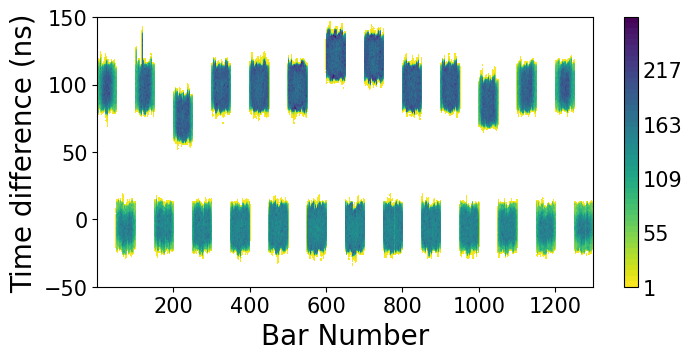

In [144]:
# data_z
fig, ax = plt.subplots()
plot = ax.contourf(data_x, data_y, data_z, cmap = 'viridis_r', levels =np.linspace(1, np.amax(data_z), 50))
ax.set_ylim(-50, 150)
ax.set_xlabel("Bar Number", fontsize = 20)
ax.set_ylabel("Time difference (ns)", fontsize = 20)
ax.tick_params(labelsize = 15)
fig.set_size_inches(8, 3.5)
cbar = fig.colorbar(plot, ticks = np.linspace(1, 271, 6))
cbar.ax.tick_params(size=0, labelsize = 15)


In [82]:
np.amax(data_z)

np.float64(269.0)

In [18]:
hist_proj = hist_time_offsets.ProjectionY("_py", 230, 230)
res = np.zeros(2)
quantiles = np.array([0.1, 0.9])
hist_proj.GetQuantiles(2, res, quantiles)
hist_proj.Draw()
print(f"lower: {res[0]}, higher: {res[1]}")
print(fit_res)

lower: 62.39631901840491, higher: 86.94111111111111
****************************************
Minimizer is Linear / Migrad
Chi2                      =      9467.96
NDf                       =           42
p0                        =     -8111.29   +/-   22.4522     
p1                        =      142.702   +/-   0.393366    



In [42]:
data = convert_to_df(hist_proj)

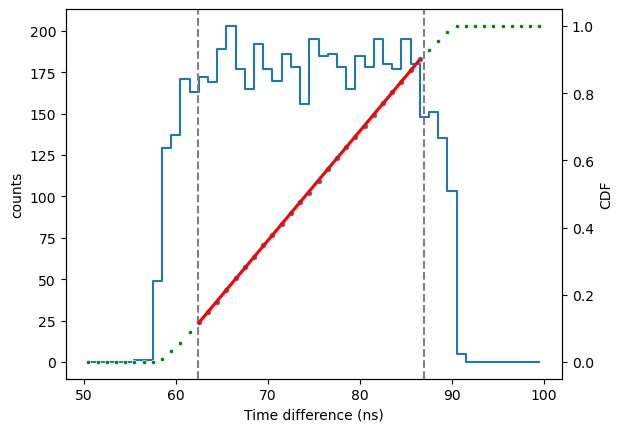

In [43]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)
ax2 = plt.twinx()
sns.scatterplot(data, x="x", y="CDF", ax=ax2, color="g", marker=".")
plt.axvline(x=res[0], color="grey", linestyle="--")
plt.axvline(x=res[1], color="grey", linestyle="--")

fit_data = data[data["x"] > res[0]]
fit_data = fit_data[fit_data["x"] < res[1]]

sns.regplot(fit_data, x="x", y="CDF", ax=ax2, marker=".", line_kws=dict(color="r"))

plt.show()

[Text(0.5, 0, 'Time difference (ns)'), Text(0, 0.5, 'counts')]

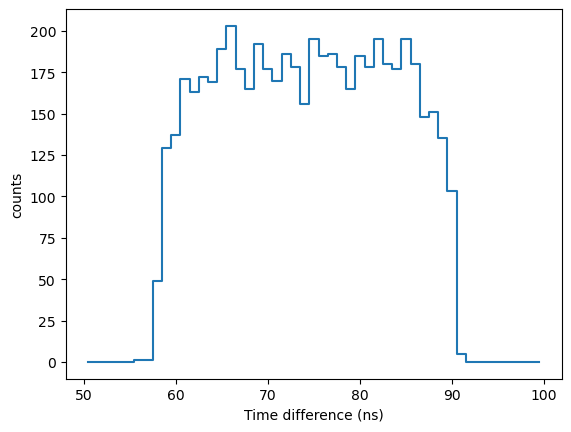

In [44]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)

[Text(0.5, 0, 'Time difference (ns)'), Text(0, 0.5, 'counts')]

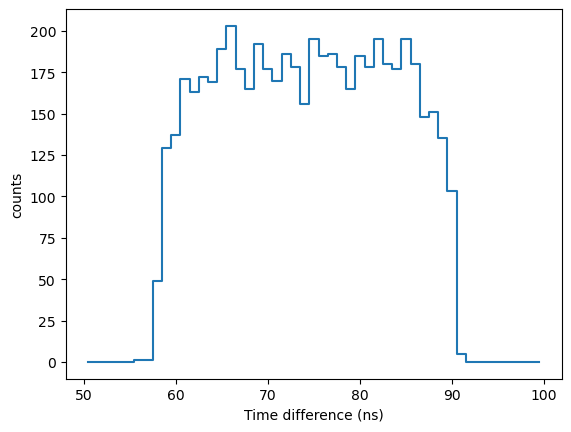

In [44]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)

[Text(0.5, 0, 'Time difference (ns)'), Text(0, 0.5, 'counts')]

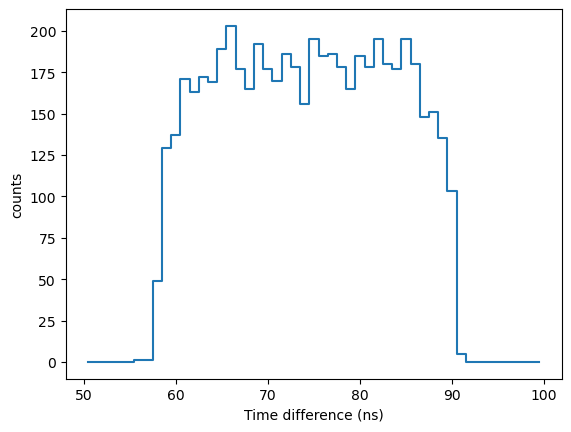

In [44]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)

<Axes: xlabel='x', ylabel='CDF'>

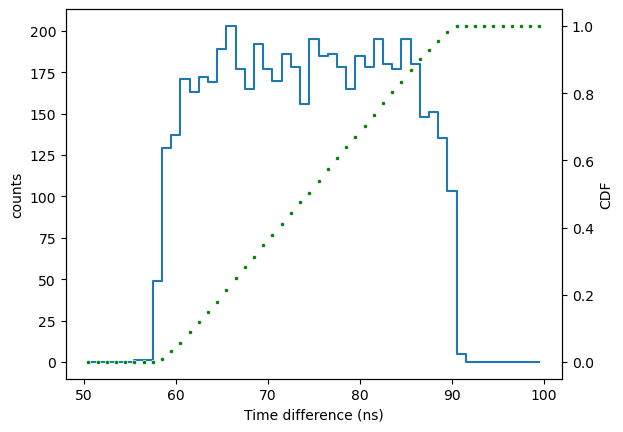

In [45]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)
ax2 = plt.twinx()
sns.scatterplot(data, x="x", y="CDF", ax=ax2, color="g", marker=".")

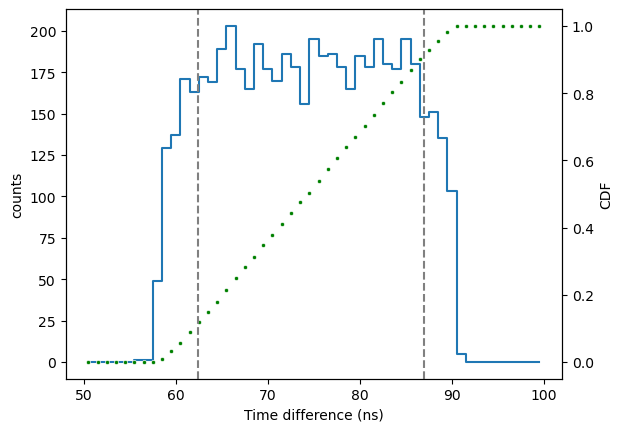

In [46]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)
ax2 = plt.twinx()
sns.scatterplot(data, x="x", y="CDF", ax=ax2, color="g", marker=".")
plt.axvline(x=res[0], color="grey", linestyle="--")
plt.axvline(x=res[1], color="grey", linestyle="--")

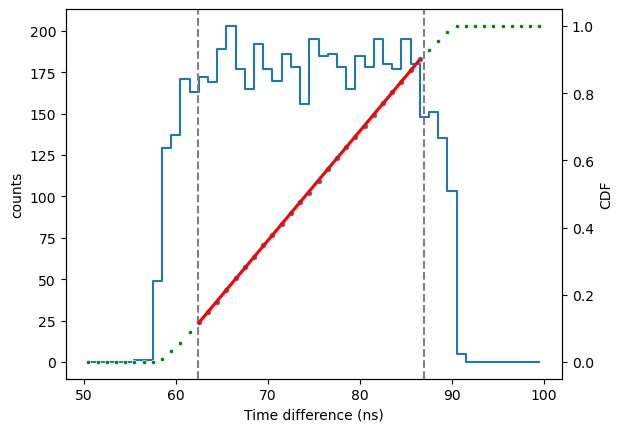

In [47]:
sns.lineplot(data, x="x", y="y", drawstyle="steps").set(
    xlabel="Time difference (ns)", ylabel="counts"
)
ax2 = plt.twinx()
sns.scatterplot(data, x="x", y="CDF", ax=ax2, color="g", marker=".")
plt.axvline(x=res[0], color="grey", linestyle="--")
plt.axvline(x=res[1], color="grey", linestyle="--")

fit_data = data[data["x"] > res[0]]
fit_data = fit_data[fit_data["x"] < res[1]]

sns.regplot(fit_data, x="x", y="CDF", ax=ax2, marker=".", line_kws=dict(color="r"))

plt.show()

In [53]:
file = "/lustre/r3b/ywang/calibration/s515/run49x/cal/cal.par.root"
root_file = ROOT.TFile(file, "read")

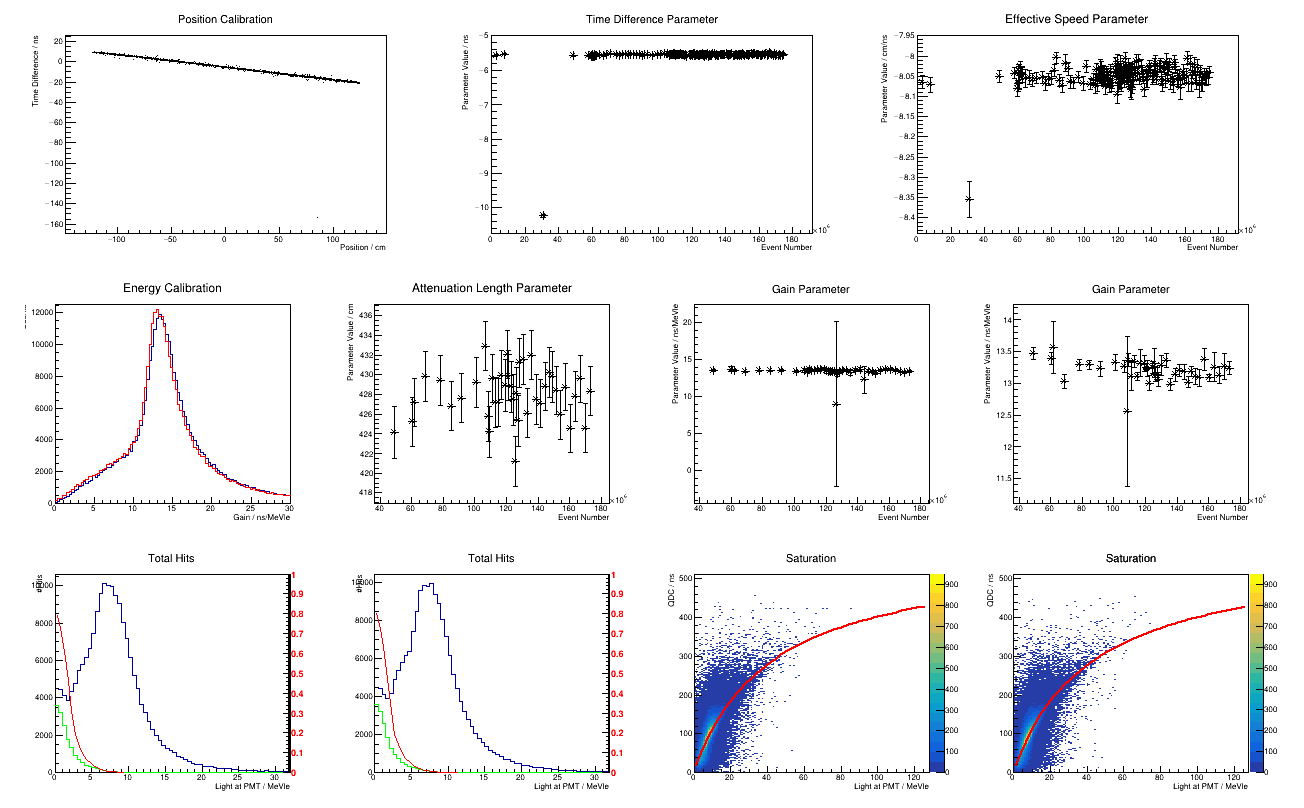

In [59]:
hist_dir = root_file.Get("Histograms/Plane_2")
hist_canvas = hist_dir.Get("Bar 70")
hist_canvas.Draw()

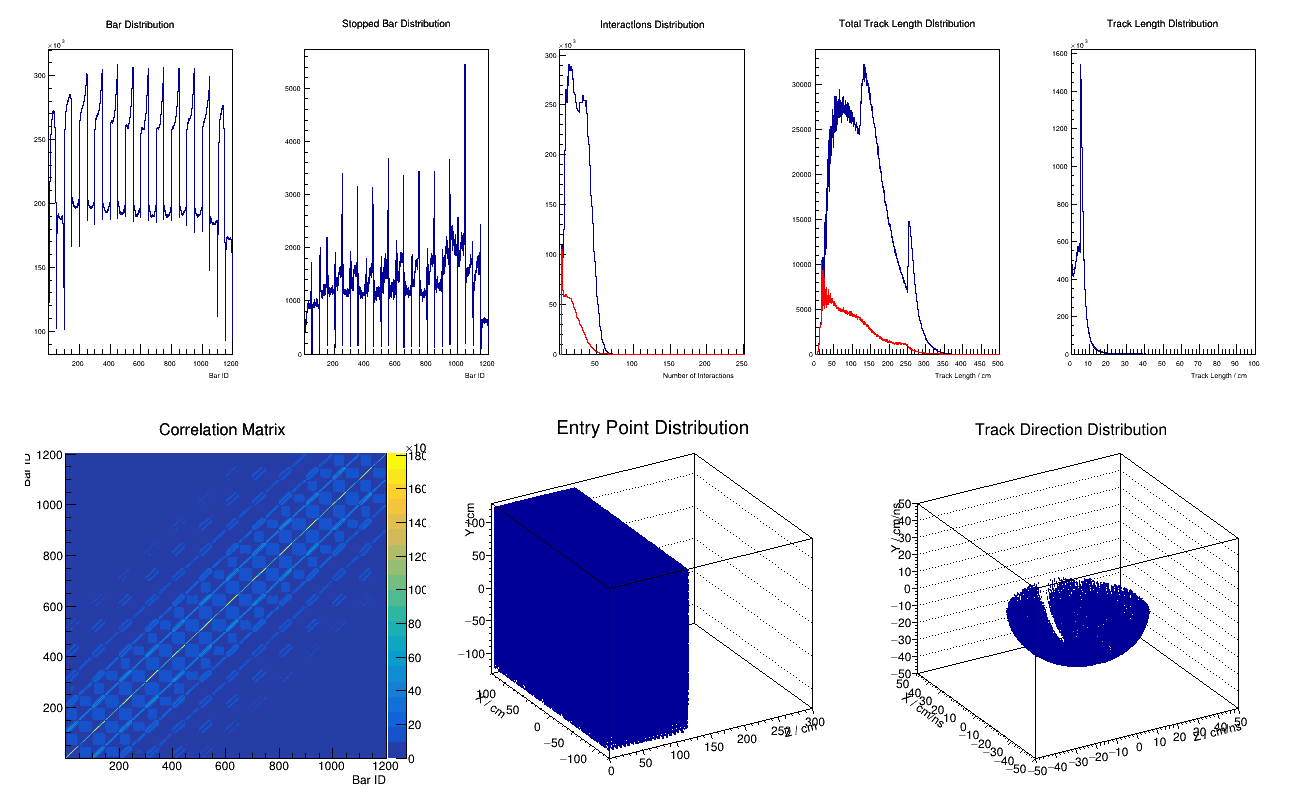

In [67]:
root_file.Get("Histograms").Get("Tracking").Draw()
# canvas2 = root_file.Get("Histograms").Get("Overview")
# canvas2.Draw()